# Intelligent Driver Model (IDM): Traffic Ring Simulation

This notebook implements the **Intelligent Driver Model** to simulate traffic flow on a circular road. The IDM is a time-continuous car-following model that describes how vehicles accelerate and decelerate based on their speed, distance to the car ahead, and relative velocity.

## Model Overview

The simulation models multiple cars traveling on a circular track, where each car's acceleration is determined by:
- **Free-road acceleration**: tendency to reach desired speed
- **Interaction term**: reaction to the car ahead (braking/maintaining safe distance)

## Import Required Libraries

Import necessary modules for numerical integration, plotting, and animation.

In [70]:
from scipy.integrate import odeint
from numpy import linspace, array, zeros, arange, sqrt, concatenate, sin, cos, pi
from matplotlib.animation import FuncAnimation
from matplotlib.pyplot import figure, subplot, show
import matplotlib.pyplot as plt

## Define the IDM Rate Function

The rate function computes the acceleration for each vehicle based on the Intelligent Driver Model equations:

$$a_{IDM} = a \left[1 - \left(\frac{v}{v_0}\right)^\delta - \left(\frac{s^*}{s}\right)^2\right]$$

where:
- $v$ = current velocity
- $v_0$ = desired velocity
- $s$ = actual gap to car ahead
- $s^* = s_0 + vT + \frac{v\Delta v}{2\sqrt{ab}}$ = desired gap
- $\Delta v$ = approach rate (velocity difference)

In [71]:
def ratefunction(t, X):
    """
    IDM rate function for multiple cars on a circular track.
    
    Parameters:
    -----------
    t : float
        Current time
    X : array
        State vector [positions, velocities]
        
    Returns:
    --------
    rate : array
        Derivative [velocities, accelerations]
    """
    # Unpack the dependent variables
    x = X[:ncar]
    v = X[ncar:]
        
    # Compute acceleration according to IDM
    dv = zeros(ncar)
    
    for i in range(ncar):
        # Acceleration on an empty road
        freeroad = (1 - (v[i]/v0)**delta_exp)
        
        # Calculate distance to car ahead
        s = x[i-1] - L - x[i]  # distance to car ahead
        if i == 0: 
            s = s + Circ  # Add circumference for first car (wraps around)
        
        delv = v[i] - v[i-1]  # approach speed to car ahead
        
        # Desired following distance
        sstar = s0 + v[i]*T + v[i]*delv/(2*sqrt(a_accel*b_decel))
        interaction = (sstar/s)**2    
        
        # IDM acceleration formula
        a_idm = a_accel*(freeroad - interaction) 
            
        # Store acceleration
        dv[i] = a_idm
    
    # Pack rate array [velocities, accelerations]
    rate = concatenate((v, dv))
    
    return rate

## Set Model Parameters

Define the IDM parameters and road/vehicle characteristics:

| Parameter | Symbol | Value | Description |
|-----------|--------|-------|-------------|
| Time headway | $T$ | 1.8 s | Desired time gap to car ahead |
| Acceleration exponent | $\delta$ | 4 | Free-road acceleration exponent |
| Vehicle length | $L$ | 5 m | Length of each car |
| Max acceleration | $a$ | 0.3 m/s² | Comfortable acceleration |
| Comfortable deceleration | $b$ | 3 m/s² | Comfortable braking |
| Desired speed | $v_0$ | 28 m/s | Target velocity (~100 km/h) |
| Minimum gap | $s_0$ | 2.0 m | Minimum desired distance |

In [72]:
# IDM parameters
T = 1.8          # time headway (s)
delta_exp = 4    # acceleration exponent
L = 5            # vehicle length (m)
a_accel = 0.3    # max acceleration (m/s^2)
b_decel = 3      # comfortable deceleration (m/s^2)
v0 = 28          # desired speed (m/s)
s0 = 2.0         # minimum gap (m)

# Road and traffic parameters
Circ = 1000      # circumference of circular track (m)
ncar = 50        # number of cars

## Set Initial Conditions

Initialize car positions evenly spaced around the ring, with all cars at rest except the first car which has a small velocity perturbation to trigger traffic wave formation.

In [73]:
# Initial positions: evenly spaced around the ring
dx_start = Circ/ncar
xinit = -dx_start*arange(ncar) 

# Initial velocities: all at rest except first car
vinit = zeros(ncar) 
vinit[0] = vinit[0] + 1  # Perturbation to trigger traffic wave

# Combine into state vector
X0 = concatenate((xinit, vinit))

print(f"Initial spacing: {dx_start:.1f} m")
print(f"Number of cars: {ncar}")
print(f"Track circumference: {Circ} m")

Initial spacing: 20.0 m
Number of cars: 50
Track circumference: 1000 m


## Solve the Differential Equations

Use `odeint` to numerically integrate the system over a 15-minute time period.

In [74]:
# Time interval
Tstart = 0
Tend = 15*60  # 15 minutes in seconds

# Form time array
time = linspace(Tstart, Tend, 400)  # 400 time steps

# Solve the ODE
X = odeint(ratefunction, X0, time, tfirst=True) 

# Unpack results
xout = X[:, 0:ncar]       # positions
vout = X[:, ncar:]  # velocities

print(f"Simulation complete: {len(time)} time steps over {Tend/60:.0f} minutes")

Simulation complete: 400 time steps over 15 minutes


## Visualize Results: Position and Velocity vs Time

Plot the trajectories of every 5th car to show how traffic waves develop and propagate through the ring.

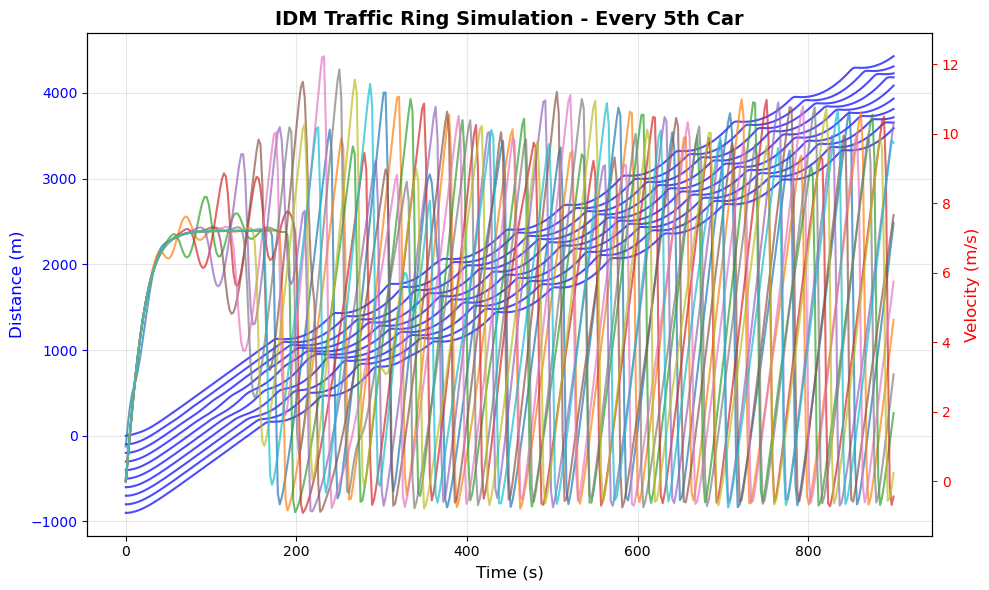

In [75]:
fig = figure(figsize=(10, 6))

# Position plot
ax1 = subplot()
ax1.plot(time, xout[:, ::5], 'b', alpha=0.7)
ax1.set_xlabel('Time (s)', fontsize=12)
ax1.set_ylabel('Distance (m)', color='b', fontsize=12)
ax1.tick_params('y', colors='b')
ax1.grid(True, alpha=0.3)

# Velocity plot on twin axis
ax2 = ax1.twinx()
ax2.plot(time, vout[:, ::5],  alpha=0.7)
ax2.set_ylabel('Velocity (m/s)', color='r', fontsize=12)
ax2.tick_params('y', colors='r')

plt.title('IDM Traffic Ring Simulation - Every 5th Car', fontsize=14, fontweight='bold')
fig.tight_layout()
show()

## Detailed Multi-Panel Plots (Optional)

Use the code below to create detailed plots showing all cars' positions and velocities.

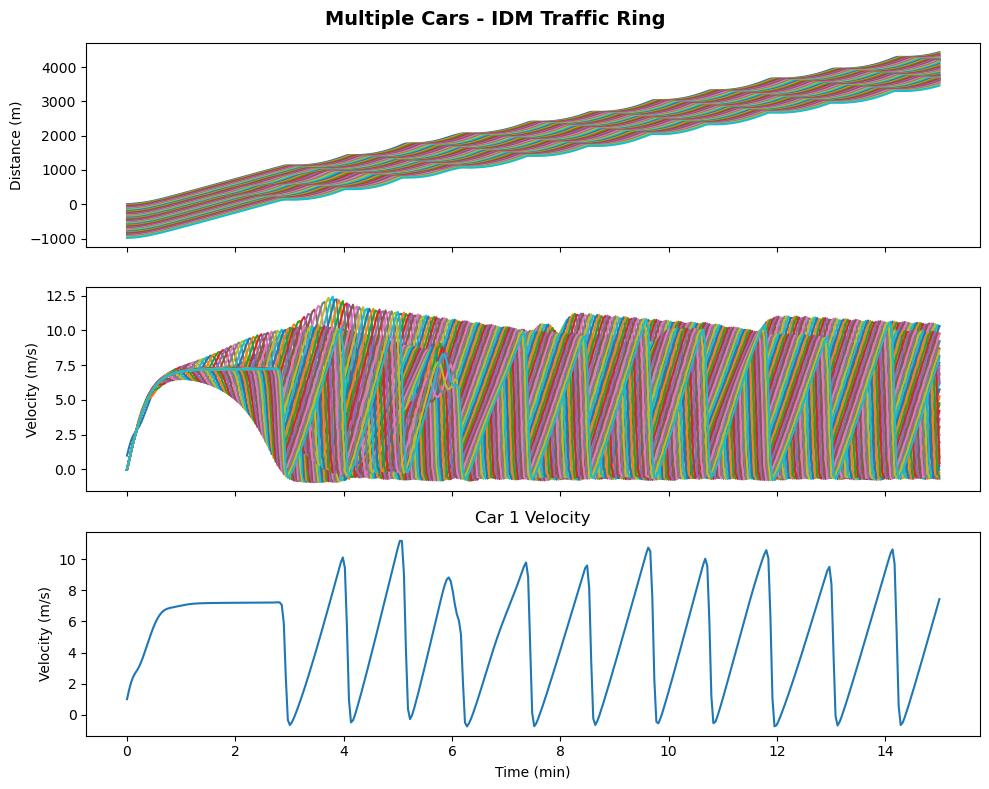

In [76]:
# Detailed plots
fig, [dplt, vplt, v1plt] = plt.subplots(3, figsize=(10, 8)) 

fig.suptitle('Multiple Cars - IDM Traffic Ring', fontsize=14, fontweight='bold')

dplt.plot(time/60, xout)
dplt.set(ylabel='Distance (m)')
dplt.label_outer()

vplt.plot(time/60, vout)
vplt.set(xlabel='Time (min)', ylabel='Velocity (m/s)')
vplt.label_outer()

v1plt.plot(time/60, vout[:, 0])
v1plt.set(xlabel='Time (min)', ylabel='Velocity (m/s)')
v1plt.set_title('Car 1 Velocity')

plt.tight_layout()
show()

## Summary and Analysis

This simulation demonstrates several key traffic phenomena:

1. **Traffic Wave Formation**: A small perturbation (initial velocity of first car) creates stop-and-go waves
2. **Wave Propagation**: Traffic jams propagate backward through the ring
3. **Emergent Behavior**: Complex traffic patterns emerge from simple car-following rules
4. **Stability Analysis**: The model parameters determine whether traffic flow is stable or develops phantom jams

### Experiment Ideas:
- Vary the number of cars (`ncar`) to see density effects
- Change `a_accel` and `b_decel` to model aggressive vs. cautious drivers
- Modify `T` (time headway) to study different following behaviors
- Try different initial perturbations to study wave formation

# A more pythonic version
This version is more efficient by using the numpy roll function to shift all the cars ahead one so that everything can be done as arrays avoiding the loop. This version runs a lot faster since loops really slow things down but array opperations are very fast.


In [77]:
def ratefunction_pythonic(t, X):
    """
    IDM rate function for multiple cars on a circular track.
    
    Parameters:
    -----------
    t : float
        Current time
    X : array
        State vector [positions, velocities]
        
    Returns:
    --------
    rate : array
        Derivative [velocities, accelerations]
    """
    from numpy import roll

    # Unpack the dependent variables
    x = X[:ncar]
    v = X[ncar:]

    # Vectorized IDM using roll for the car ahead
    x_ahead = roll(x, 1)
    v_ahead = roll(v, 1)

    # Calculate distance to car ahead
    s = x_ahead - L - x
    s[0] = s[0] + Circ  # Add circumference for first car (wraps around)

    # approach speed to car ahead   
    delv = v - v_ahead  

    # Desired following distance
    sstar = s0 + v*T + v*delv/(2*sqrt(a_accel*b_decel))

    # IDM acceleration formula
    dv = a_accel*(1 - (v/v0)**delta_exp - (sstar/s)**2)

    # Pack rate array [velocities, accelerations]
    rate = concatenate((v, dv))

    return rate